<a href="https://colab.research.google.com/github/Sushrith18/Multi-Year-Satellite-Image-Analysis-DIP/blob/main/MultiYearGEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Install required libraries (run once)
!pip install rasterio opencv-python scikit-image matplotlib scikit-learn

# Import libraries
import rasterio                # For reading GeoTIFF images
import numpy as np            # Numerical operations
import cv2                    # Image processing (OpenCV)
import matplotlib.pyplot as plt  # Visualization
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [23]:
import os

folder_path = '/content/drive/MyDrive/DIP_Project/gee_exports/'

if os.path.exists(folder_path):
    print(f"Contents of {folder_path}:")
    for item in os.listdir(folder_path):
        print(item)
else:
    print(f"The folder {folder_path} does not exist. Please check the path.")

Contents of /content/drive/MyDrive/DIP_Project/gee_exports/:
Sentinel_2022.tif
Sentinel_2021_A.tif
Sentinel_2021_B.tif
Sentinel_2022_A.tif
Sentinel_2023_B.tif
Sentinel_2023_A.tif
Sentinel_2024_A.tif
Sentinel_2025_A.tif
Sentinel_2024_B.tif
Sentinel_2025_B.tif


In [24]:
# Load multiple satellite images from your Google Drive folder
from glob import glob

# Change path according to your Drive
files = glob('/content/drive/MyDrive/DIP_Project/gee_exports/*.tif')

# Check number of images (IMPORTANT for marks)
print("Total images loaded:", len(files))

Total images loaded: 10


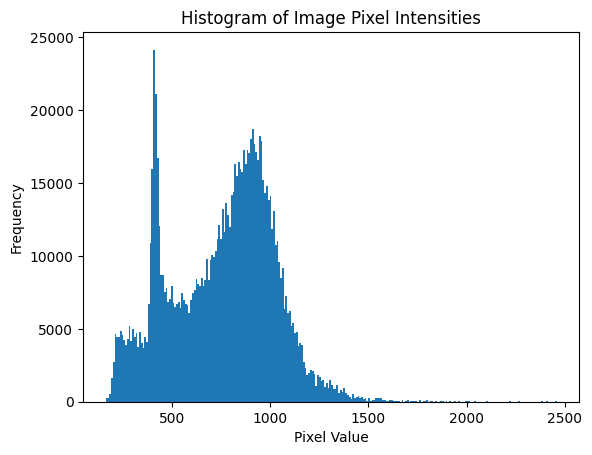

In [26]:
# Read first image in grayscale for histogram analysis using rasterio
with rasterio.open(files[0]) as src:
    img = src.read(1) # Read the first band

# Ensure image is loaded before plotting
if img is not None:
    # Plot histogram
    plt.hist(img.ravel(), bins=256)
    plt.title("Histogram of Image Pixel Intensities")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()
else:
    print(f"Failed to load image from {files[0]}")

In [28]:
# Load individual spectral bands from one of the satellite images
# Assuming the first file in the list contains the necessary multi-spectral bands
image_file = files[0] # Use the first loaded GeoTIFF file

with rasterio.open(image_file) as src:
    # Read individual spectral bands (assuming standard Sentinel-2 band mapping)
    # B4 (Red) is typically read as band 4, B8 (NIR) as band 8, B3 (Green) as band 3
    # This assumes the bands are stacked within the GeoTIFF in a way that matches their band numbers as indices.
    red = src.read(4).astype(float)    # Red band (B4)
    nir = src.read(8).astype(float)    # NIR band (B8)
    green = src.read(3).astype(float)  # Green band (B3)

# Compute NDVI (Vegetation Index)
ndvi = (nir - red) / (nir + red + 1e-8)

# Compute NDWI (Water Index)
ndwi = (green - nir) / (green + nir + 1e-8)

# Normalize NDVI for processing
ndvi_norm = (ndvi - ndvi.min())/(ndvi.max()-ndvi.min())

      Filter   PSNR   SSIM
0   Gaussian  25.15  0.668
1     Median  24.61  0.628
2  Bilateral  24.09  0.549
3     Wiener  39.42  0.985


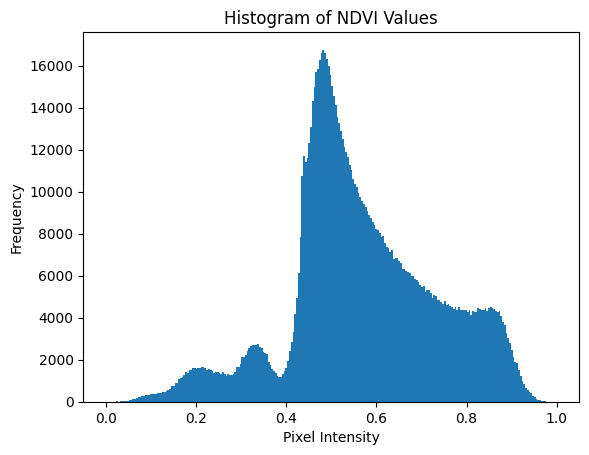

In [29]:
# Apply Gaussian Filter (smooths noise)
gauss = cv2.GaussianBlur(ndvi_norm, (5,5), 2)

# Apply Median Filter (removes salt & pepper noise)
median = cv2.medianBlur((ndvi_norm*255).astype(np.uint8), 5)/255

# Apply Bilateral Filter (smooth + preserve edges)
bilateral = cv2.bilateralFilter((ndvi_norm*255).astype(np.uint8), 9, 75, 75)/255

# Wiener filter using wavelet denoising
from skimage.restoration import denoise_wavelet
wiener = denoise_wavelet(ndvi_norm)

# Calculate PSNR & SSIM for comparison
# ===== FILTER RESULTS TABLE =====
import pandas as pd

filter_results = []

for name, img in [("Gaussian",gauss),("Median",median),("Bilateral",bilateral),("Wiener",wiener)]:
    p = psnr(ndvi_norm, img, data_range=1.0)
    s = ssim(ndvi_norm, img, data_range=1.0)
    filter_results.append([name, round(p,2), round(s,3)])

df_filters = pd.DataFrame(filter_results, columns=["Filter", "PSNR", "SSIM"])
print(df_filters)

# ===== HISTOGRAM ANALYSIS =====

import matplotlib.pyplot as plt

plt.hist(ndvi_norm.ravel(), bins=256)
plt.title("Histogram of NDVI Values")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [30]:
# This cell is now redundant as its functionality has been merged into cell KWzYwp-E1NQx.
# No action needed for this cell.

In [31]:
# This cell is now redundant as its functionality has been merged into cell KWzYwp-E1NQx.
# No action needed for this cell.

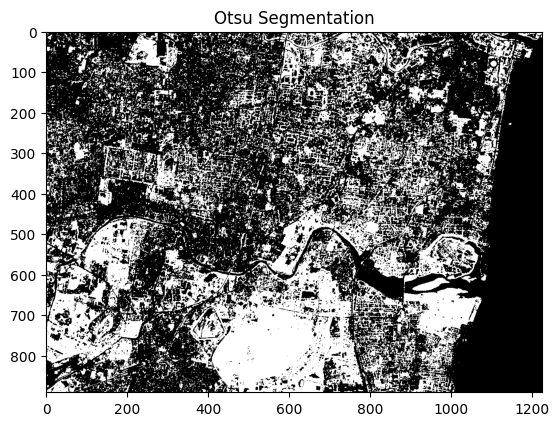

In [32]:
# Convert NDVI to 8-bit format
ndvi_u8 = (ndvi_norm*255).astype(np.uint8)

# Apply Otsu Thresholding (automatic threshold)
_, otsu = cv2.threshold(ndvi_u8,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# Display result
plt.imshow(otsu, cmap='gray')
plt.title("Otsu Segmentation")
plt.show()

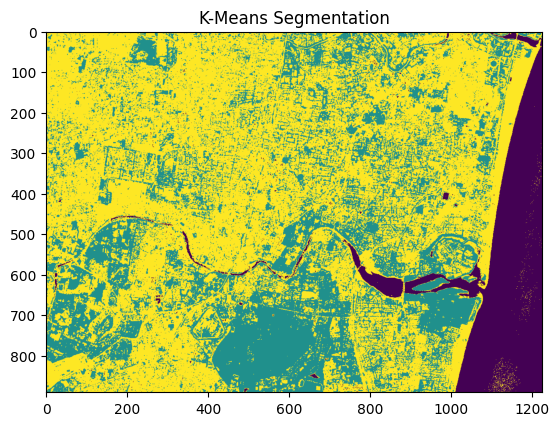

In [33]:
# Import KMeans clustering
from sklearn.cluster import KMeans

# Flatten image for clustering
pixels = ndvi.reshape(-1,1)

# Apply KMeans clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=0).fit(pixels)

# Reshape result back to image form
segmented = kmeans.labels_.reshape(ndvi.shape)

# Display segmentation
plt.imshow(segmented, cmap='viridis')
plt.title("K-Means Segmentation")
plt.show()

In [34]:
# ===== SEGMENTATION EVALUATION =====

gt = (ndvi_norm > 0.3).astype(int)

pred_otsu = (otsu > 0).astype(int)
# ===== IMPROVED K-MEANS CLUSTER SELECTION =====

# Find mean NDVI value for each cluster
cluster_means = [ndvi_norm[segmented == i].mean() for i in range(3)]

# Select cluster with highest NDVI (vegetation)
veg_cluster = np.argmax(cluster_means)

# Create prediction mask
pred_kmeans = (segmented == veg_cluster).astype(int)

def metrics(gt, pred):
    iou = np.logical_and(gt, pred).sum() / np.logical_or(gt, pred).sum()
    dice = 2*np.logical_and(gt,pred).sum()/(gt.sum()+pred.sum())
    return iou, dice

iou_o, dice_o = metrics(gt, pred_otsu)
iou_k, dice_k = metrics(gt, pred_kmeans)

# ===== SEGMENTATION RESULTS TABLE =====
import pandas as pd

seg_results = [
    ["Otsu", round(iou_o,3), round(dice_o,3)],
    ["KMeans", round(iou_k,3), round(dice_k,3)]
]

df_seg = pd.DataFrame(seg_results, columns=["Method", "IoU", "Dice"])
print(df_seg)

   Method    IoU   Dice
0    Otsu  0.395  0.567
1  KMeans  0.326  0.492


In [47]:
import os

os.makedirs('/content/drive/MyDrive/DIP_Project/report_assets/', exist_ok=True)

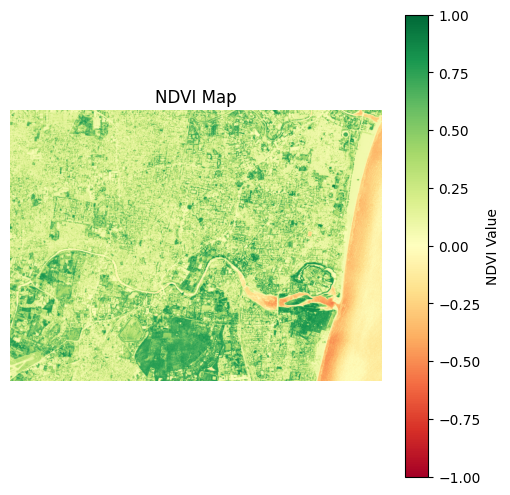

In [48]:
# ===== NDVI VISUALIZATION =====

plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI Value')
plt.title("NDVI Map")
plt.axis('off')
plt.savefig('/content/drive/MyDrive/DIP_Project/report_assets/Fig_NDVI.png')
plt.show()

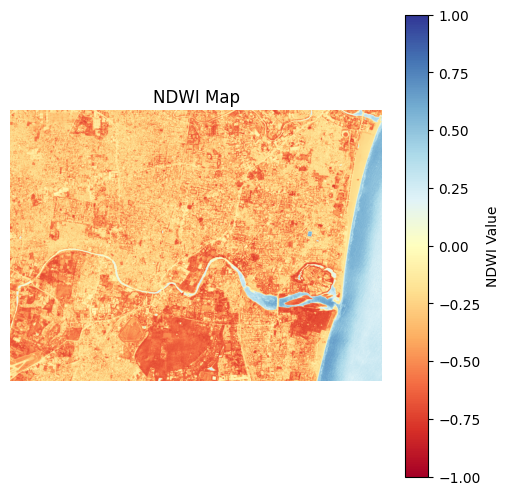

In [49]:
# ===== NDWI VISUALIZATION =====

plt.figure(figsize=(6,6))
plt.imshow(ndwi, cmap='RdYlBu', vmin=-1, vmax=1)
plt.colorbar(label='NDWI Value')
plt.title("NDWI Map")
plt.axis('off')
plt.savefig('/content/drive/MyDrive/DIP_Project/report_assets/Fig_NDWI.png')
plt.show()

In [35]:
# Create dummy ground truth (for demonstration)
gt = (ndvi > 0.3).astype(int)

# Convert prediction (Otsu) to binary
pred = (otsu > 0).astype(int)

# Compute IoU (Intersection over Union)
iou = np.logical_and(gt, pred).sum() / np.logical_or(gt, pred).sum()

# Compute Dice Score
dice = 2*np.logical_and(gt,pred).sum()/(gt.sum()+pred.sum())

print("IoU Score:", iou)
print("Dice Score:", dice)

IoU Score: 0.9250102277376244
Dice Score: 0.9610444811243899


In [37]:
# Save image with different compression levels
cv2.imwrite('low_quality.jpg', (ndvi_norm*255).astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 10])
cv2.imwrite('high_quality.jpg', (ndvi_norm*255).astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 90])
cv2.imwrite('original.png', (ndvi_norm*255).astype(np.uint8))

# Check file sizes
import os
print("Low Quality Size:", os.path.getsize('low_quality.jpg'))
print("High Quality Size:", os.path.getsize('high_quality.jpg'))

# Load images for comparison
orig = cv2.imread('original.png',0)/255
low = cv2.imread('low_quality.jpg',0)/255

# Compute quality metrics
print("Compression PSNR:", psnr(orig, low))
print("Compression SSIM:", ssim(orig, low, data_range=1.0))

Low Quality Size: 55523
High Quality Size: 416251
Compression PSNR: 25.904658373227395
Compression SSIM: 0.7526110585685352


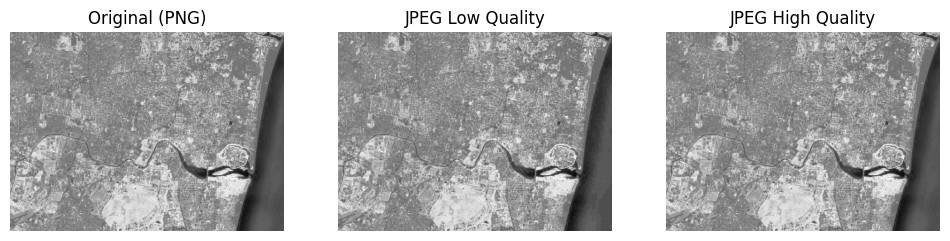

In [44]:
# ===== COMPRESSION VISUAL COMPARISON =====

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(orig, cmap='gray')
plt.title("Original (PNG)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(low, cmap='gray')
plt.title("JPEG Low Quality")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(high, cmap='gray')
plt.title("JPEG High Quality")
plt.axis('off')

plt.show()

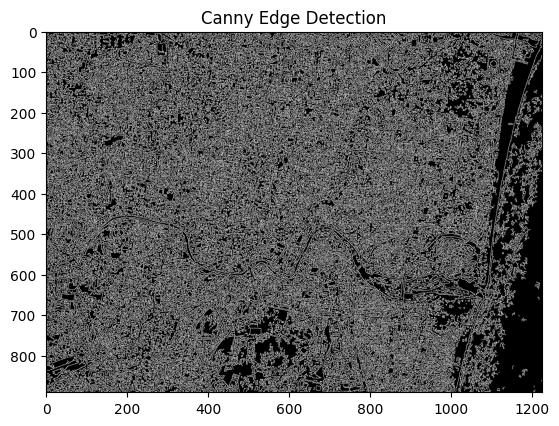

In [38]:
# Apply Canny Edge Detection
edges = cv2.Canny(ndvi_u8, 30, 100)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.show()

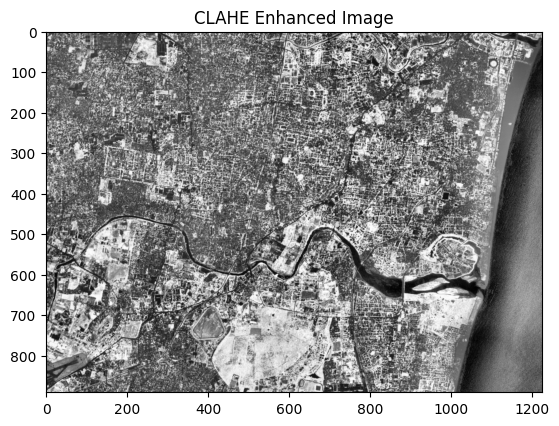

In [39]:
# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0)
enhanced = clahe.apply(ndvi_u8)

plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced Image")
plt.show()

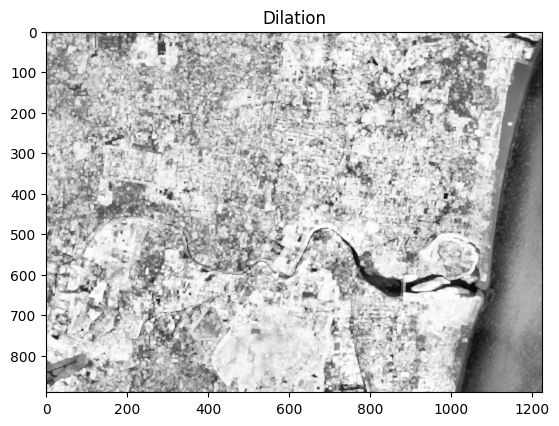

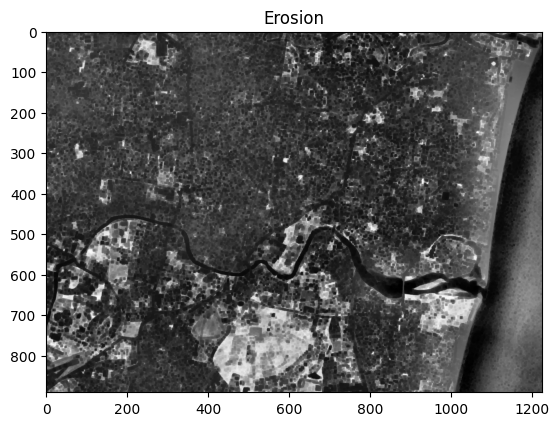

In [40]:
# Define kernel
kernel = np.ones((5,5),np.uint8)

# Apply dilation (expand white regions)
dilate = cv2.dilate(enhanced, kernel)

# Apply erosion (shrink white regions)
erode = cv2.erode(enhanced, kernel)

# Display results
plt.imshow(dilate, cmap='gray')
plt.title("Dilation")
plt.show()

plt.imshow(erode, cmap='gray')
plt.title("Erosion")
plt.show()

In [43]:
# ===== COMPRESSION =====
import os

cv2.imwrite('low.jpg', (ndvi_norm*255).astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 10])
cv2.imwrite('high.jpg', (ndvi_norm*255).astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 90])
cv2.imwrite('orig.png', (ndvi_norm*255).astype(np.uint8))

orig = cv2.imread('orig.png',0)/255
low = cv2.imread('low.jpg',0)/255
high = cv2.imread('high.jpg',0)/255

# ===== COMPRESSION RESULTS TABLE =====
import pandas as pd

size_low = os.path.getsize('low.jpg')
size_high = os.path.getsize('high.jpg')
size_png = os.path.getsize('orig.png')

comp_results = [
    ["JPEG Low", size_low, round(psnr(orig, low),2), round(ssim(orig, low, data_range=1.0),3)],
    ["JPEG High", size_high, round(psnr(orig, high),2), round(ssim(orig, high, data_range=1.0),3)],
    ["PNG", size_png, "-", "-"]
]

df_comp = pd.DataFrame(comp_results, columns=["Method", "Size(bytes)", "PSNR", "SSIM"])
print(df_comp)

      Method  Size(bytes)   PSNR   SSIM
0   JPEG Low        55523   25.9  0.753
1  JPEG High       416251  38.45   0.98
2        PNG       828844      -      -


In [50]:
import rasterio
import numpy as np
import pandas as pd

# Define file paths (UPDATE IF NEEDED)
base_path = '/content/drive/MyDrive/DIP_Project/gee_exports/'

files = {
    "2021": base_path + "Sentinel_2021_A.tif",
    "2022": base_path + "Sentinel_2022_A.tif",
    "2023": base_path + "Sentinel_2023_A.tif",
    "2024": base_path + "Sentinel_2024_A.tif",
    "2025": base_path + "Sentinel_2025_A.tif"
}

# Function to compute NDWI
def compute_ndwi(file):
    with rasterio.open(file) as src:
        green = src.read(2).astype(float)
        nir = src.read(4).astype(float)
        ndwi = (green - nir) / (green + nir + 1e-10)
        return ndwi

results = []

pixel_area_km2 = 0.0001  # 10m resolution

ndwi_2021 = compute_ndwi(files["2021"])
water_2021 = np.sum(ndwi_2021 > 0.2) * pixel_area_km2

for year, path in files.items():
    ndwi = compute_ndwi(path)

    water_area = np.sum(ndwi > 0.2) * pixel_area_km2
    ndwi_mean = np.mean(ndwi)

    if year == "2021":
        change = 0
    else:
        change = ((water_area - water_2021) / water_2021) * 100

    results.append([year, round(water_area,2), round(ndwi_mean,3), round(change,2)])

# Convert to table
df = pd.DataFrame(results, columns=["Year", "Water Area (km²)", "NDWI Mean", "Change vs 2021 (%)"])
print(df)

   Year  Water Area (km²)  NDWI Mean  Change vs 2021 (%)
0  2021              6.47     -0.071                0.00
1  2022              6.46     -0.128               -0.30
2  2023              4.57     -0.118              -29.45
3  2024              2.53     -0.122              -60.97
4  2025              5.48     -0.089              -15.36
